In [6]:
from simbanator.analysis import HDF5BuildHistory
from simbanator.io.simba import Simulation
from matplotlib import pyplot as plt

# Load your simulation (use the name you configured)
sim = Simulation("cis100")  # Replace XX with your snapshot number
cs = sim.load_catalog(snap=129)
sim.get_z_from_snap(129)
progen = False

yt : [INFO     ] 2026-04-12 17:21:56,312 Opening /mnt/home/share/simbas/SIMBA_100/Groups/m100n1024_129.hdf5


[Simulation] Loading snap→z mapping from: /mnt/home/glorenzon/analize_simba_cgm/simbanator/data/snap_z_maps/zsnap_map_caesar_box100.txt


yt : [INFO     ] 2026-04-12 17:21:57,102 Found 495012 halos
yt : [INFO     ] 2026-04-12 17:21:58,475 Found 46575 galaxies


In [2]:
import numpy as np
from astropy.cosmology import Planck18 as cosmo

sfr = np.asarray([i.sfr for i in cs.galaxies])
m   = np.asarray([i.masses['stellar'] for i in cs.galaxies])
ssfr = sfr/m
qgs = ssfr < 1e-11
dust = np.asarray([i.masses['dust'] for i in cs.galaxies])
glist = np.asarray([i.ngas for i in cs.galaxies])
dts = dust/m
ids = np.asarray([i.GroupID for i in cs.galaxies])
sel_dusty_qgs = (np.log10(m)>10.9) & (ssfr<2e-11) & (dust/m > 1e-4) & (glist>50)
sel_dusty_sf  = (np.log10(m)>10.9) & (ssfr>2e-10) & (dust/m > 1e-3) & (glist>50)

In [3]:
print(glist[sel_dusty_qgs])
print(glist[sel_dusty_sf])

[225 273 254 153 160 197 488  54  62 135 181  52  92]
[2872 2035 2735 2114 2206 2330 2171 1614 1753 1786 1017 1685 2904 1255
  713 2301 3492 1544 2183  462]


13


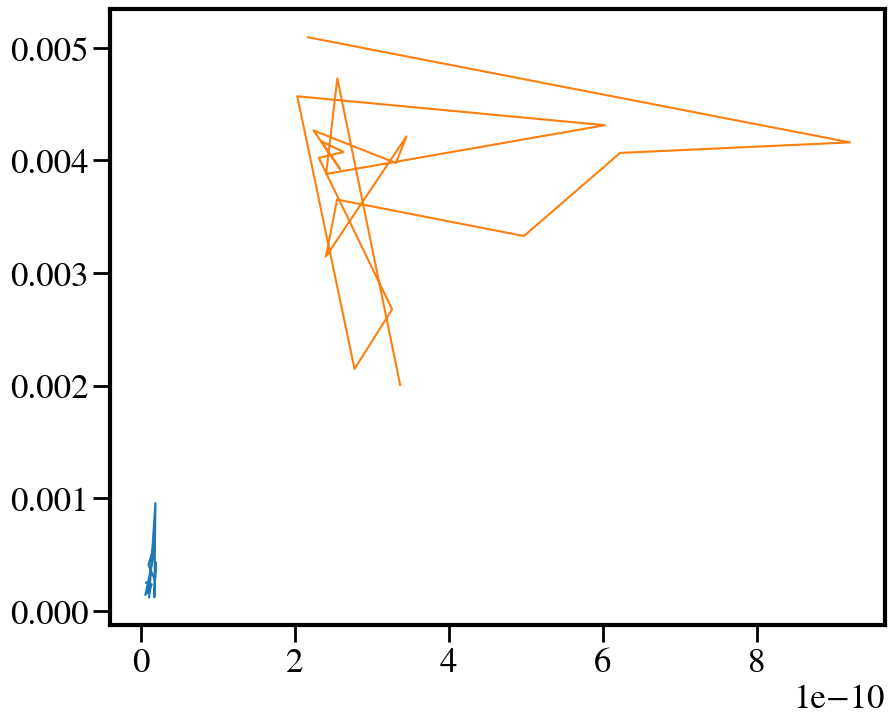

In [4]:
print(len(m[sel_dusty_qgs]))
plt.plot(ssfr[sel_dusty_qgs], dust[sel_dusty_qgs]/m[sel_dusty_qgs])
plt.plot(ssfr[sel_dusty_sf], dust[sel_dusty_sf]/m[sel_dusty_sf])

(array([ 323.87572878,    0.        ,  161.93786439,  161.93786439,
         161.93786439,  161.93786439, 1133.56505074,  647.75145757,
         323.87572878,  161.93786439]),
 array([0.00200603, 0.00231479, 0.00262355, 0.00293231, 0.00324107,
        0.00354983, 0.00385859, 0.00416736, 0.00447612, 0.00478488,
        0.00509364]),
 <BarContainer object of 10 artists>)

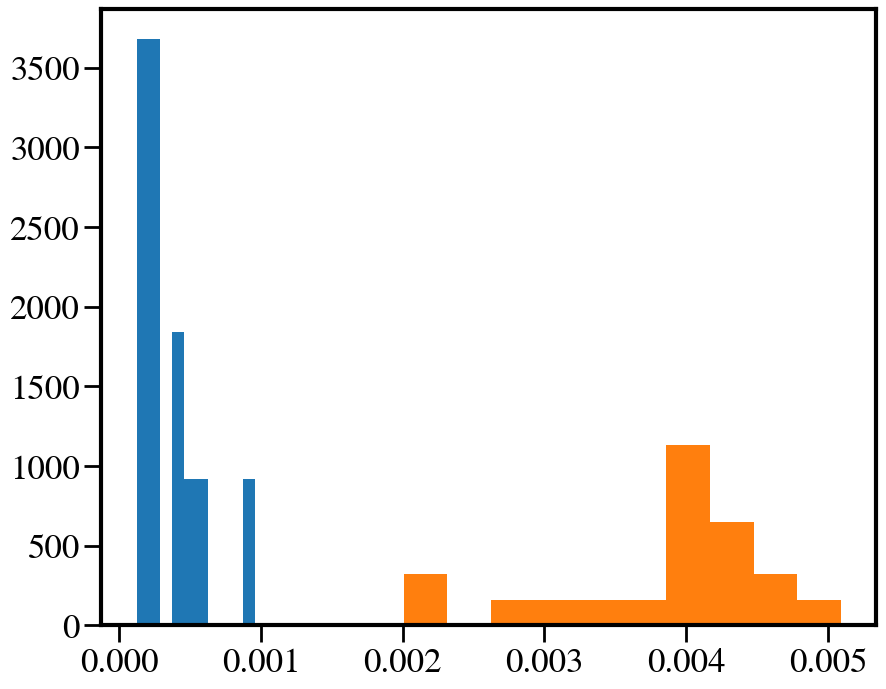

In [5]:
plt.hist(dust[sel_dusty_qgs]/m[sel_dusty_qgs], density=True)
plt.hist(dust[sel_dusty_sf]/m[sel_dusty_sf], density=True)

In [6]:
maxd_qg  = np.where(dts == dts[sel_dusty_qgs].max())[0]
mind_sf  = np.where(dts == dts[sel_dusty_sf].min())[0]

print(ids[maxd_qg], ids[mind_sf])
print(glist[maxd_qg], glist[mind_sf])
print(dts[maxd_qg], dts[mind_sf])
print(m[maxd_qg], m[mind_sf])

[950] [990]
[52] [462]
[0.00095804] [0.00200603]
[8.172834e+10] [7.95403878e+10]


In [27]:
from simbanator.analysis.particles import extract_particles
extract_particles(
    cs,
    sim.get_snapshot_file(129),
    snap=129,
    galaxy_ids=[950,990],   # list of galaxies
    sim_name=sim.name,
    overwrite=True,
    prefix='m100n1024'
)

Reading snapshot once for batch extraction: /mnt/home/share/simbas/SIMBA_100/snap_m100n1024_129.hdf5
gal 950 PartType0 particles: 52
gal 950 PartType4 particles: 5220
Finished extraction -> /mnt/home/glorenzon/analize_simba_cgm/output/cis100/filtered/snap_129/m100n1024_snap129_gal000950.h5
gal 990 PartType0 particles: 462
gal 990 PartType4 particles: 5084
Finished extraction -> /mnt/home/glorenzon/analize_simba_cgm/output/cis100/filtered/snap_129/m100n1024_snap129_gal000990.h5


['/mnt/home/glorenzon/analize_simba_cgm/output/cis100/filtered/snap_129/m100n1024_snap129_gal000950.h5',
 '/mnt/home/glorenzon/analize_simba_cgm/output/cis100/filtered/snap_129/m100n1024_snap129_gal000990.h5']

In [7]:
# initialize SED making class
import os
from simbanator.sed.makesed import MakeSED
hydro_dir_base = os.path.join(os.getcwd(), 'output', sim.name, 'filtered')
selection_file = 'selection_simba100_qgs_dust_off_no_AGB.hdf5'
makesed = MakeSED(sim, nnodes=1, model_run_name='QGs_dust_off_no_AGB', 
                  hydro_dir_base=hydro_dir_base, selection_file=selection_file
                 )


makesed.selection_gals(snaps=[129, 129], galaxyID=[950,990]) # create the hdf5 selection
makesed.create_master('cluster', 'plist', radius=None, partition='INTEL_PHI', prefix='m100n1024', paramf='parameters_master-nodust.py', snaps_to_run=None) # create the parameters masters

yt : [INFO     ] 2026-04-12 17:22:07,619 Opening /mnt/home/share/simbas/SIMBA_100/Groups/m100n1024_129.hdf5
yt : [INFO     ] 2026-04-12 17:22:07,832 Found 495012 halos
yt : [INFO     ] 2026-04-12 17:22:08,005 Found 46575 galaxies


Written data for snap129
writing slurm submission master script file
/mnt/home/glorenzon/analize_simba_cgm/output/cis100/sed/QGs_dust_off_no_AGB/powderday_sed_out/snap_129/master.snap129.job


In [9]:
makesed.plotsed(129, 950)

In [27]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# =============================
# Load SED models
# =============================
makesed_dust = MakeSED(
    sim, nnodes=1,
    model_run_name='QGs_dust_on',
    hydro_dir_base=hydro_dir_base,
    selection_file=selection_file
)

makesed_no_dust = MakeSED(
    sim, nnodes=1,
    model_run_name='QGs_dust_off_no_AGB',
    hydro_dir_base=hydro_dir_base,
    selection_file=selection_file
)

snap = 129

# =============================
# Extract SEDs
# =============================
lam_990_d, f_990_d = makesed_dust.plotsed(snap, 990, retval=True)
lam_950_nd, f_950_nd = makesed_no_dust.plotsed(snap, 950, retval=True)
lam_950_d, f_950_d = makesed_dust.plotsed(snap, 950, retval=True)

# take first component + convert to mJy
f_990_d = f_990_d[0]
f_950_nd = f_950_nd[0]
f_950_d = f_950_d[0]

# =============================
# Sort (important for log plots)
# =============================
# def sort_xy(x, y):
#     idx = np.argsort(x)
#     return x[idx], y[idx]

# lam_990, f_990_d = sort_xy(lam_990, f_990_d)
# lam_950_nd, f_950_nd = sort_xy(lam_950_nd, f_950_nd)
# lam_950_d, f_950_d = sort_xy(lam_950_d, f_950_d)

# =============================
# Plot settings
# =============================
lw = 4
xmin, xmax = 1e-1, 1e3
ymin, ymax = 1e-4, 1e2

# =============================
# Plot 1: Dusty star-forming
# =============================
plt.figure()

plt.loglog(lam_990_d, f_990_d, linewidth=lw, label='Dusty star-forming')

plt.xlabel('Wavelength [$\\mu$m]')
plt.ylabel('Flux [mJy]')
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)

plt.legend()

plt.savefig('onlydust_990.png', bbox_inches='tight')


# =============================
# Plot 2: Dusty SF + Quiescent
# =============================
plt.figure()

plt.loglog(lam_990_d, f_990_d, linewidth=lw, label='Dusty star-forming')
plt.loglog(lam_950_nd, f_950_nd, '--', linewidth=lw, label='Quiescent')

plt.xlabel('Wavelength [$\\mu$m]')
plt.ylabel('Flux [mJy]')
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)

plt.legend()

plt.savefig('dust_990_nodust_950.png', bbox_inches='tight')


# ==================|===========
# Plot 3: All three
# =============================
plt.figure()

plt.loglog(lam_990_d, f_990_d, linewidth=lw, label='Dusty star-forming')
plt.loglog(lam_950_nd, f_950_nd, '--', linewidth=lw, label='Quiescent')
plt.loglog(lam_950_d, f_950_d, ':', linewidth=lw, label='Dusty quiescent')

plt.xlabel('Wavelength [$\\mu$m]')
plt.ylabel('Flux [mJy]')
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)

plt.legend()

plt.savefig('dust_990_nodust_950_dust_950.png', bbox_inches='tight')